# XOR Swizzling for GPU Shared Memory

GPU shared memory is divided into **banks** (typically 32 banks).
When multiple threads in a warp access the **same bank** simultaneously, they serialize — this is a **bank conflict**.

A common scenario: you load a matrix tile into shared memory row-by-row,
then later read it column-by-column (e.g., for a transpose or matmul).
Column access hits the same bank for every thread → N-way bank conflict.

**XOR swizzling** remaps the column index so that column accesses spread across different banks.

In [11]:
import numpy as np

## The Problem: Bank Conflicts on Column Access

Assume a 4×4 shared memory tile with 4 banks (simplified from 32).
Each element's bank = `column index % num_banks`.

When threads read column 0, every row maps to bank 0 → 4-way conflict!

In [12]:
S = 4  # tile size (use 4 for clarity; real GPU uses 32)
NUM_BANKS = S

A = np.arange(S * S).reshape(S, S)
print("Matrix A (values = flat index):")
print(A)
print()

# Bank assignment: bank[i,j] = j % NUM_BANKS
banks = np.array([[j % NUM_BANKS for j in range(S)] for i in range(S)])
print("Bank layout (bank = col % 4):")
print(banks)
print()
print("Reading column 0: all rows hit bank 0 → 4-way conflict!")
print(f"  Banks accessed: {banks[:, 0].tolist()}")

Matrix A (values = flat index):
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]]

Bank layout (bank = col % 4):
[[0 1 2 3]
 [0 1 2 3]
 [0 1 2 3]
 [0 1 2 3]]

Reading column 0: all rows hit bank 0 → 4-way conflict!
  Banks accessed: [0, 0, 0, 0]


## The Fix: XOR Swizzling

Instead of storing `A[i, j]` at column `j`, store it at column `i XOR j`.

Now when threads read a logical column, each row maps to a **different physical column** (and thus a different bank).

In [13]:
def xor_swizzle(A):
    """Store A[i,j] at physical column (i ^ j)."""
    S, _ = A.shape
    O = np.zeros_like(A)
    for i in range(S):
        for j in range(S):
            O[i, i ^ j] = A[i, j]
    return O

swizzled = xor_swizzle(A)
print("Original layout in shared memory:")
print(A)
print()
print("Swizzled layout in shared memory:")
print(swizzled)

Original layout in shared memory:
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]]

Swizzled layout in shared memory:
[[ 0  1  2  3]
 [ 5  4  7  6]
 [10 11  8  9]
 [15 14 13 12]]


## Why It Works

To read logical column `j`, thread at row `i` now reads physical column `i ^ j`.

Since `i` is different for each row, `i ^ j` gives a different physical column per row → no bank conflicts.

In [14]:
def show_access_pattern(logical_col, S=4):
    """Show which physical column (bank) each row accesses for a given logical column."""
    print(f"Reading logical column {logical_col}:")
    phys_cols = []
    for row in range(S):
        phys_col = row ^ logical_col
        phys_cols.append(phys_col)
        print(f"  Row {row}: physical col = {row} ^ {logical_col} = {phys_col} (bank {phys_col % S})")
    print(f"  Banks accessed: {phys_cols} — all different!")
    print()

for col in range(S):
    show_access_pattern(col)

Reading logical column 0:
  Row 0: physical col = 0 ^ 0 = 0 (bank 0)
  Row 1: physical col = 1 ^ 0 = 1 (bank 1)
  Row 2: physical col = 2 ^ 0 = 2 (bank 2)
  Row 3: physical col = 3 ^ 0 = 3 (bank 3)
  Banks accessed: [0, 1, 2, 3] — all different!

Reading logical column 1:
  Row 0: physical col = 0 ^ 1 = 1 (bank 1)
  Row 1: physical col = 1 ^ 1 = 0 (bank 0)
  Row 2: physical col = 2 ^ 1 = 3 (bank 3)
  Row 3: physical col = 3 ^ 1 = 2 (bank 2)
  Banks accessed: [1, 0, 3, 2] — all different!

Reading logical column 2:
  Row 0: physical col = 0 ^ 2 = 2 (bank 2)
  Row 1: physical col = 1 ^ 2 = 3 (bank 3)
  Row 2: physical col = 2 ^ 2 = 0 (bank 0)
  Row 3: physical col = 3 ^ 2 = 1 (bank 1)
  Banks accessed: [2, 3, 0, 1] — all different!

Reading logical column 3:
  Row 0: physical col = 0 ^ 3 = 3 (bank 3)
  Row 1: physical col = 1 ^ 3 = 2 (bank 2)
  Row 2: physical col = 2 ^ 3 = 1 (bank 1)
  Row 3: physical col = 3 ^ 3 = 0 (bank 0)
  Banks accessed: [3, 2, 1, 0] — all different!



## Visual: Before vs After Swizzling

Color = bank assignment. Without swizzling, each column is one color (conflict).
With swizzling, each column has all different colors (no conflict).

Matplotlib is building the font cache; this may take a moment.


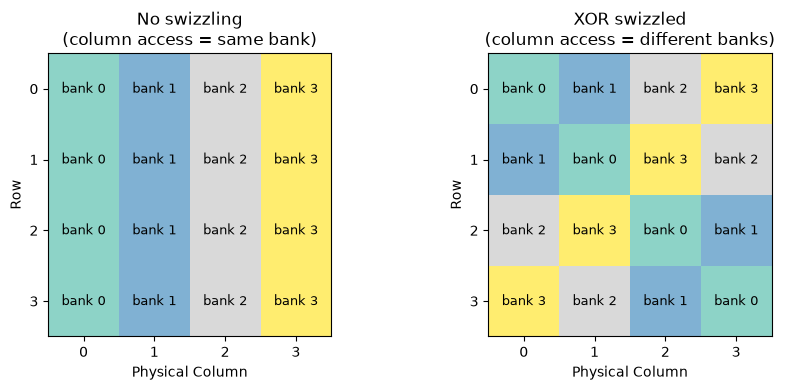

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))

# Bank assignment before and after swizzling
banks_before = np.array([[j % S for j in range(S)] for i in range(S)])
banks_after = np.array([[(i ^ j) % S for j in range(S)] for i in range(S)])

cmap = plt.cm.Set3

for ax, data, title in [(ax1, banks_before, "No swizzling\n(column access = same bank)"),
                         (ax2, banks_after, "XOR swizzled\n(column access = different banks)")]:
    ax.imshow(data, cmap=cmap, vmin=0, vmax=S-1)
    for i in range(S):
        for j in range(S):
            ax.text(j, i, f"bank {data[i,j]}", ha='center', va='center', fontsize=9)
    ax.set_xticks(range(S))
    ax.set_yticks(range(S))
    ax.set_xlabel("Physical Column")
    ax.set_ylabel("Row")
    ax.set_title(title)

plt.tight_layout()
plt.show()

## Reading Back: Deswizzle

XOR is its own inverse: applying `i ^ j` twice gives back `j`.
So to read logical element `A[i, j]` from the swizzled layout, just read physical column `i ^ j`.

In [16]:
def xor_deswizzle(O):
    """Read back: logical A[i,j] lives at physical column (i ^ j)."""
    S, _ = O.shape
    A = np.zeros_like(O)
    for i in range(S):
        for j in range(S):
            A[i, j] = O[i, i ^ j]
    return A

recovered = xor_deswizzle(swizzled)
print("Recovered original from swizzled layout:")
print(recovered)
print(f"\nMatches original: {np.array_equal(A, recovered)}")

Recovered original from swizzled layout:
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]]

Matches original: True


## Summary

| | Row access | Column access |
|---|---|---|
| **No swizzle** | No conflict | N-way conflict |
| **XOR swizzle** | No conflict | No conflict |

The key insight: `row XOR col` produces a unique value for each row when col is fixed,
and a unique value for each col when row is fixed. Both access patterns are conflict-free.

In practice (e.g., CUTLASS, Triton), this is done with a single XOR on the address bits — zero overhead.